# Лабораторная работа #7
#### Дисциплина: _"Методы Оптимизации"_ ####


#### Выполнили: __Сафин Максим Владиславович__ (P3222) | __Фокин Владимир Сергеевич__ (P3223) ####

## Исходные данные
Исследуемая функция: $ f(x, y) = 10^{-2}(8x^2 + 2xy + 17x + 4y + 2) $

Диапазон: $ (x, y) \in [-20, 20] \times [-50, 50] $

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(_x, _y):
    """Исследуемая функция"""
    return 0.01 * (8*_x**2 + 2*_x*_y + 17*_x + 4*_y + 2)

## Задание 1

### 1.1 Поиск и анализ стационарных точек

Частные производные первого порядка:  

$ \frac{\partial f}{\partial x}=10^{-2}(16x+2y+17),\qquad $
$ \frac{\partial f}{\partial y}=10^{-2}(2x+4). $

Стационарные точки находим из системы

$ \begin{cases} 16x+2y+17=0,\\ 2x+4=0. \end{cases} $

Из второго уравнения $ (x=-2) $. Подставляя в первое: 

$ 16(-2)+2y+17=0 \;\Rightarrow\; -32+2y+17=0 \;\Rightarrow\; y=7{,}5. $

Единственная стационарная точка: $ S(-2;\;7{,}5) $.

Исследуем её характер. Вторые производные:

$ \frac{\partial^{2}f}{\partial x^{2}}=10^{-2}\cdot16=0{,}16,\quad $
$ \frac{\partial^{2}f}{\partial y\partial x}=10^{-2}\cdot2=0{,}02,\quad $
$ \frac{\partial^{2}f}{\partial y^{2}}=0. $

Матрица Гессе

$
H=\begin{pmatrix}
0{,}16 & 0{,}02\\
0{,}02 & 0
\end{pmatrix}.
$

Главные миноры: 

$D_{1}=0{,}16>0$,

$D_{2}=\det H=-0{, }0004<0$. Гессиан знакопеременный, следовательно, \(S\) – **седловая точка**. Локальных экстремумов функция не имеет.

### 1.2 Глобальный минимум в заданной области

Функция непрерывна на замкнутом прямоугольнике $[-20,20]\times[-50,50]$, поэтому по теореме Вейерштрасса достигает минимального и максимального значений.
Внутри области имеется только седловая точка $S(-2,\,7.5)$, следовательно, минимум находится на границе.

Рассмотрим все четыре границы:

**1. Нижняя граница $y = -50$:**

$ f(x,-50) = 0.01\bigl(8x^2 + 2x(-50) + 17x + 4(-50) + 2\bigr) = 0.01(8x^2 - 83x - 198). $

Квадратичная функция с положительным старшим коэффициентом; минимум на этом ребре достигается в вершине параболы

$x_0 = \frac{83}{2\cdot8} = \frac{83}{16} = 5.1875 \in [-20,20]. $

Значение в вершине:

$f(5.1875, -50) = 0.01\left(8\Bigl(\frac{83}{16}\Bigr)^2 – 83\cdot\frac{83}{16} – 198\right) \approx -4.1328. $

**2. Верхняя граница $y = 50$:**

$f(x,50) = 0.01(8x^2 + 2x\cdot50 + 17x + 4\cdot50 + 2) = 0.01(8x^2 + 117x + 202).$

Вершина: $x = -\dfrac{117}{2\cdot8} = -7.3125 \in [-20,20]$.
Значение: $f(-7.3125, 50) \approx -2.257$.

**3. Левая граница $x = -20$:**

$f(-20,y) = 0.01(8\cdot400 + 2(-20)y + 17(-20) + 4y + 2) = 0.01(2862 - 36y).$

Линейная функция; минимум при $y=50$: $f(-20,50) = 10.62$.

**4. Правая граница $x = 20$:**

$f(20,y) = 0.01(8\cdot400 + 2\cdot20y + 17\cdot20 + 4y + 2) = 0.01(3542 + 44y).$

Линейная функция; минимум при $y=-50$: $f(20,-50) = 13.42$.

Сравнивая найденные значения:
- $f(5.1875,-50) \approx -4.133$,
- $f(-7.3125,50) \approx -2.257$,
- $f(-20,50) = 10.62$,
- $f(20,-50) = 13.42$.

Наименьшее значение достигается на нижней границе в вершине параболы.

**Глобальный минимум в области:**

$f_{\min} \approx -4.133 $ в точке $ (5.1875,\; -50).$

**Выводы:**
На прямоугольнике $[-20,20]\times[-50,50]$ функция имеет
- седловую точку $S(-2,\,7.5)$,
- глобальный минимум на границе в точке $(5.1875,\,-50)$.

#### Построение линий уровня

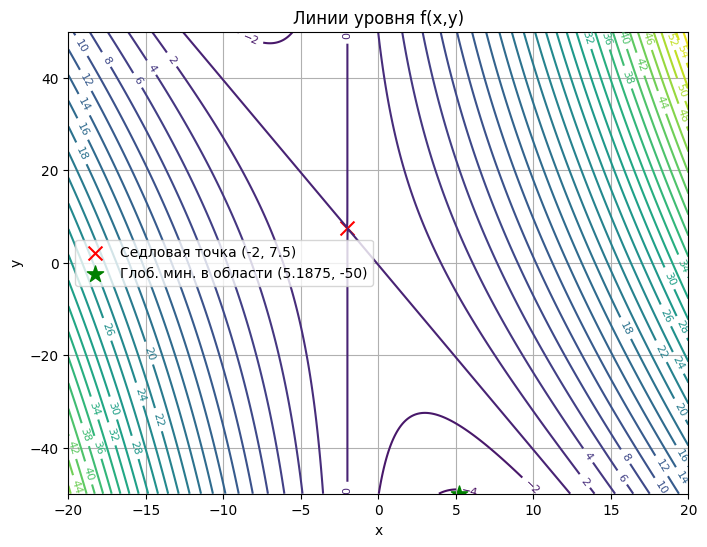

In [2]:
# Сетка
x = np.linspace(-20, 20, 400)
y = np.linspace(-50, 50, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Линии уровня
plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, Z, levels=30, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)
plt.scatter(-2, 7.5, color='red', marker='x', s=100, label='Седловая точка (-2, 7.5)')
plt.scatter(5.1875, -50, color='green', marker='*', s=150, label='Глоб. мин. в области (5.1875, -50)')
plt.title('Линии уровня f(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Задание 2

### 2.1 Иллюстрация сходимости градиентного спуска к седловой точке

Критерий останова (Δf) на итерации 90
Финальная точка: (-2.0254, 7.4720)
Норма градиента: 0.004645
Всего итераций: 90


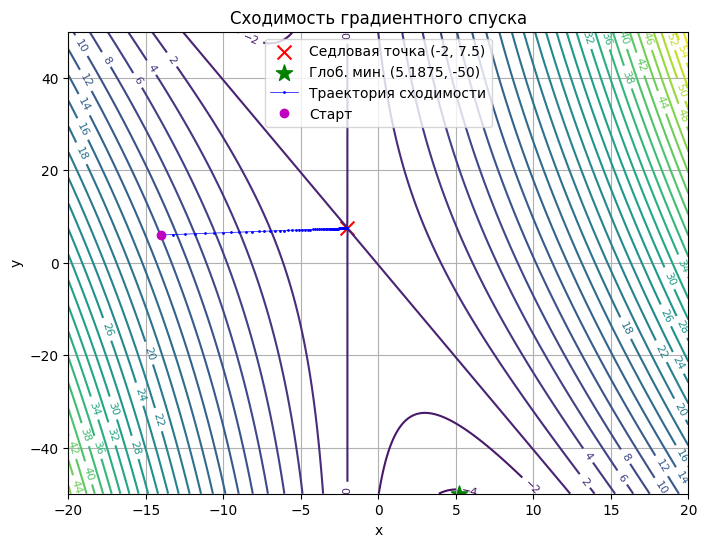

In [3]:
def grad_f(_x, _y):
    """Градиент (частные производные)"""
    df_dx = 0.01 * (16*_x + 2*_y + 17)
    df_dy = 0.01 * (2*_x + 4)
    return np.array([df_dx, df_dy])

# Начальные параметры
x0 = np.array([-14.0, 6.0]) # начальное приближение
alpha = 0.4          # скорость обучения
eps = 1e-5           # порог по изменению функции
max_iter = 100       # максимальное число итераций

trajectory = [x0.copy()]
x = x0.copy()
prev_f = f(*x)       # используем вашу функцию f

for i in range(max_iter):
    g = grad_f(*x)
    x = x - alpha * g
    trajectory.append(x.copy())
    cur_f = f(*x)
    if abs(cur_f - prev_f) < eps:
        print(f'Критерий останова (Δf) на итерации {i+1}')
        break
    prev_f = cur_f

trajectory = np.array(trajectory)
iter_count = len(trajectory)-1
print(f'Финальная точка: ({x[0]:.4f}, {x[1]:.4f})')
print(f'Норма градиента: {np.linalg.norm(grad_f(*x)):.6f}')
print(f'Всего итераций: {iter_count}')

# Сетка для контуров
x_vals = np.linspace(-20, 20, 400)
y_vals = np.linspace(-50, 50, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, Z, levels=30, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)
# Седловая точка
plt.scatter(-2, 7.5, color='red', marker='x', s=100, label='Седловая точка (-2, 7.5)')
# Глобальный минимум в области
plt.scatter(5.1875, -50, color='green', marker='*', s=150, label='Глоб. мин. (5.1875, -50)')
# Траектория градиентного спуска
plt.plot(trajectory[:, 0], trajectory[:, 1], 'b-o', markersize=1, linewidth=0.5, label='Траектория сходимости')
plt.plot(trajectory[0, 0], trajectory[0, 1], 'mo', markersize=6, label='Старт')
plt.title('Сходимость градиентного спуска')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### 2.2 Эвристики градиентного спуска — метод Поляка

Метод Поляка (или тяжёлого шарика) добавляет к градиентному спуску инерцию:
на каждом шаге часть предыдущего направления сохраняется, что помогает
«проскакивать» седловые точки и не застревать в оврагах.

**Скоростная форма** (через скорость \(v\))

$
\begin{aligned}
v_{k+1} &= \beta\, v_k - \alpha \nabla f(x_k),\\
x_{k+1} &= x_k + v_{k+1}.
\end{aligned}
$, где

$ \alpha $ – скорость обучения (learning rate),
$ \beta $ – коэффициент момента (обычно 0.9 или 0.95).

Финальная точка: (1.4166, -20.0644)
Значение функции: -0.949677


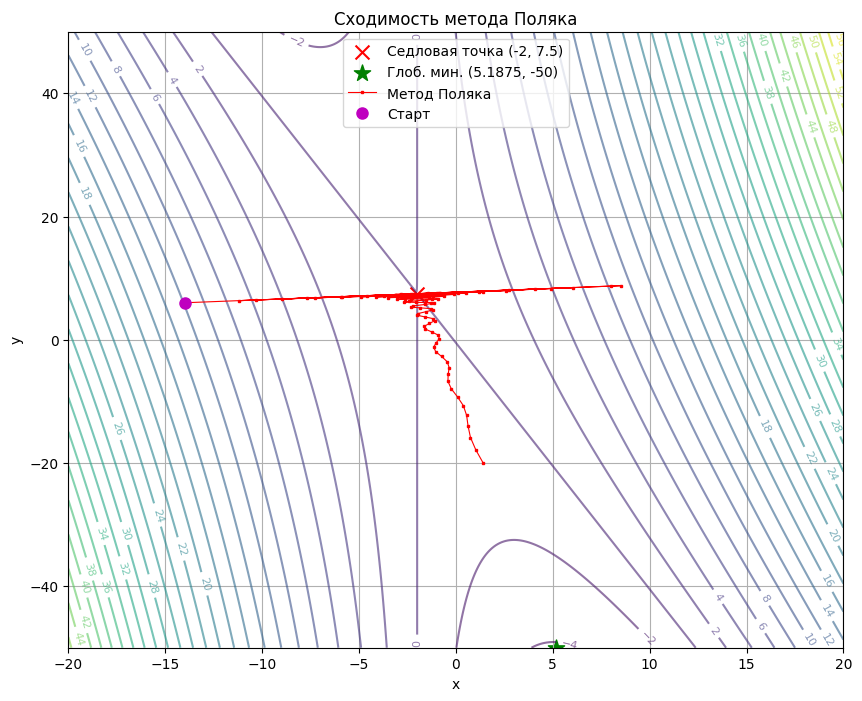

In [4]:
def sgd_trajectory(_alpha, _beta):
    """
    Функция вычисления траектории сходимости SGD с моментом
    :param _alpha скорость обучения
    :param _beta коэффициент момента
    """
    _x = x0.copy()
    _v = np.zeros(2)
    traj = [_x.copy()]
    for _i in range(iter_count):
        _g = grad_f(*_x)
        _v = _beta * _v - _alpha * _g
        _x = _x + _v
        traj.append(_x.copy())
    return _x, np.array(traj)

x, trajectory_momentum = sgd_trajectory(_alpha=6.0, _beta=0.9)
print(f'Финальная точка: ({x[0]:.4f}, {x[1]:.4f})')
print(f'Значение функции: {f(*x):.6f}')

plt.figure(figsize=(10, 8))
# Линии уровня
contours = plt.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)

# Особые точки
plt.scatter(-2, 7.5, color='red', marker='x', s=100, label='Седловая точка (-2, 7.5)')
plt.scatter(5.1875, -50, color='green', marker='*', s=150, label='Глоб. мин. (5.1875, -50)')

# Траектория
plt.plot(trajectory_momentum[:, 0], trajectory_momentum[:, 1], 'r-s', markersize=2, linewidth=0.8, label='Метод Поляка')
plt.plot(trajectory_momentum[0, 0], trajectory_momentum[0, 1], 'mo', markersize=8, label='Старт')

plt.title('Сходимость метода Поляка')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### 2.3 Настройка гиперпараметров и области отображения

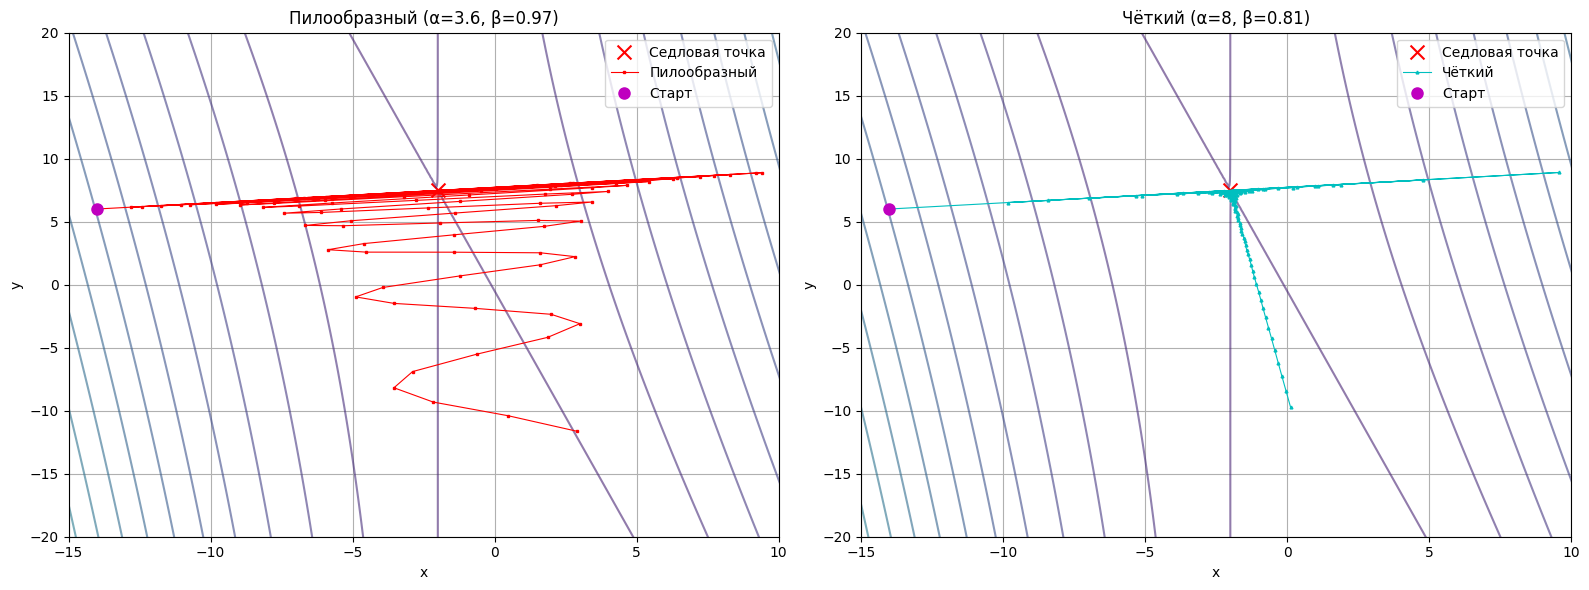

In [5]:
# Параметры для пилообразной ломаной
alpha_pila = 3.6
beta_pila = 0.97

# Параметры для гладкой ломаной
alpha_chet = 8
beta_chet = 0.81

#Вычисляем траектории для разных значений гиперпараметров
x_pila, traj_pila = sgd_trajectory(alpha_pila, beta_pila)
x_chet, traj_chet = sgd_trajectory(alpha_chet, beta_chet)

# Создаём subplots: 1 строка, 2 колонки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ----- Пилообразный -----
cont1 = ax1.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.6)
ax1.clabel(cont1, inline=True, fontsize=8)
ax1.scatter(-2, 7.5, color='red', marker='x', s=100, label='Седловая точка')
ax1.plot(traj_pila[:,0], traj_pila[:,1], 'r-s', markersize=2, linewidth=0.8, label='Пилообразный')
ax1.plot(traj_pila[0,0], traj_pila[0,1], 'mo', markersize=8, label='Старт')
ax1.set_xlim(-15, 10)
ax1.set_ylim(-20, 20)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True)
ax1.set_title(f'Пилообразный (α={alpha_pila}, β={beta_pila})')

# ----- Чёткий -----
cont2 = ax2.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.6)
ax2.clabel(cont2, inline=True, fontsize=8)
ax2.scatter(-2, 7.5, color='red', marker='x', s=100, label='Седловая точка')
ax2.plot(traj_chet[:,0], traj_chet[:,1], 'c-^', markersize=2, linewidth=0.8, label='Чёткий')
ax2.plot(traj_chet[0,0], traj_chet[0,1], 'mo', markersize=8, label='Старт')
ax2.set_xlim(-15, 10)
ax2.set_ylim(-20, 20)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend()
ax2.grid(True)
ax2.set_title(f'Чёткий (α={alpha_chet}, β={beta_chet})')

plt.tight_layout()
plt.show()

### 2.4 Реализация эвристики из пакета PyTorch - Adam

Adam: финальная точка (-4.1634, 26.7033)


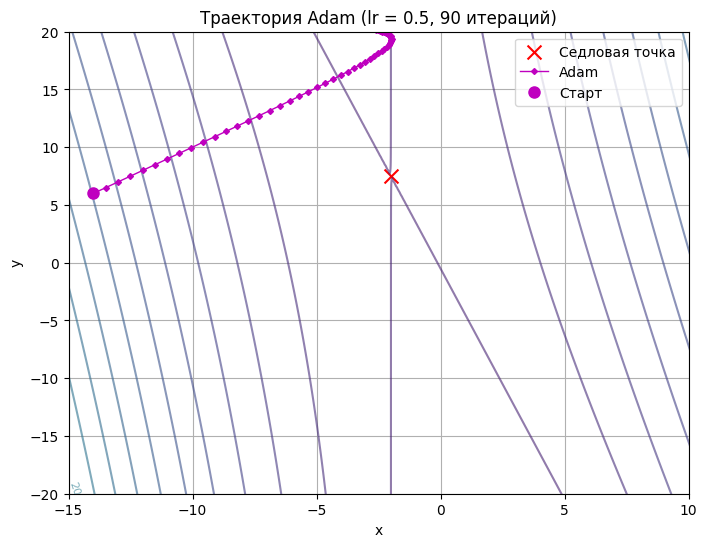

In [6]:
import torch

# Начальная точка как тензор с requires_grad=True
solution = torch.tensor([[x0[0]], [x0[1]]], dtype=torch.float32, requires_grad=True)

# Скорость обучения
lr = 0.5

# Оптимизатор Adam
optimizer = torch.optim.Adam([solution], lr)

traj_adam = []
for i in range(iter_count):
    optimizer.zero_grad()
    # вычисляем значение функции
    loss = 0.01 * (8*solution[0]**2 + 2*solution[0]*solution[1] + 17*solution[0] + 4*solution[1] + 2)
    loss.backward()
    # сохраняем текущую точку (перед шагом)
    traj_adam.append(solution.clone().detach().numpy().flatten())
    optimizer.step()

traj_adam = np.array(traj_adam)

# Вывод финальной точки
x_final, y_final = traj_adam[-1]
print(f'Adam: финальная точка ({x_final:.4f}, {y_final:.4f})')

plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)
plt.scatter(-2, 7.5, color='red', marker='x', s=100, label='Седловая точка')
plt.plot(traj_adam[:,0], traj_adam[:,1], 'm-D', markersize=3, linewidth=1, label='Adam')
plt.plot(traj_adam[0,0], traj_adam[0,1], 'mo', markersize=8, label='Старт')
plt.xlim(-15, 10)
plt.ylim(-20, 20)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.title(f'Траектория Adam (lr = {lr}, {iter_count} итераций)')
plt.show()

## Задание 3

### Предметная область и датасет

**Minecraft** – популярная компьютерная игра с открытым миром, состоящим из блоков.
Каждый **чанк** (chunk) – это вертикальная колонна размером 16×16 блоков, для которой записано распределение всех типов блоков, а также доминирующий биом.

Датасет [Minecraft chunks](https://www.kaggle.com/datasets/pi1lot/minecraft-chunks) содержит более 10 000 чанков и **1073 признака** (количество блоков каждого типа, например `minecraft:stone`, `minecraft:dirt`). Датасет удовлетворяет требованиям:
- **≥20 признаков** (используем все типы блоков, исключая координаты),
- **≥100 объектов** (обучающая выборка > 8000),
- **дата публикации > 2010 г.**

### Постановка задачи МО

- **Тип задачи:** многоклассовая классификация.
- **Целевая переменная:** `dominant_biome` (категория биома, например, `plains`, `forest`, `ocean` и т. д.).
- **Признаки:** количество блоков каждого типа в чанке (несколько сотен числовых колонок).
- **Функция потерь:** кросс-энтропия (`CrossEntropyLoss`).
- **Метрика качества:** точность (accuracy) на тестовой выборке.

In [7]:
from pandas import DataFrame
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

# Загрузка файла датасета
df = DataFrame(pd.read_csv('data.csv'))

# Отделим признаки: все столбцы, начинающиеся на 'minecraft:'
feature_cols = [c for c in df.columns if c.startswith('minecraft:')]
# Целевая переменная
target_col = 'dominant_biome'

X = df[feature_cols].values
y = df[target_col].values

# Кодируем метки классов в числа
le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)
print(f'Число классов: {num_classes}, признаков: {len(feature_cols)}')

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Нормализация признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Преобразуем в тензоры PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# DataLoader'ы
batch_size = 128
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Число классов: 18, признаков: 299


### Архитектура нейронной сети

Используется многослойный перцептрон (MLP) с тремя полно связными слоями:

1. Входной слой: `Linear(input_dim, 256)`
2. Скрытый слой: `Linear(256, 256)`
3. Выходной слой: `Linear(256, num_classes)`

Функция активации – **ReLU**, регуляризация – **Dropout(p=0.3)** после каждого скрытого слоя.

In [8]:
# Класс нейронной сети перцептрона
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, _num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, _num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, _x):
        _x = self.relu(self.fc1(_x))
        _x = self.dropout(_x)
        _x = self.relu(self.fc2(_x))
        _x = self.dropout(_x)
        _x = self.fc3(_x)          # выход без активации – logits
        return _x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP(input_dim=len(feature_cols), hidden_dim=256, _num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()

### План обучения

Модель обучается дважды с одинаковыми начальными весами:
1. **Готовый оптимизатор Adam** (из PyTorch) – бейзлайн.
2. **Собственный оптимизатор PolyakSGD** – SGD с моментом (метод Поляка), реализованный наследованием от `torch.optim.Optimizer`.

Для каждого оптимизатора собирается история потерь и точности на обучающей и тестовой выборках (30 эпох). Результаты визуализируются и сравниваются.

#### Готовый оптимизатор Adam (PyTorch) 

In [9]:
def train_epoch(_model, loader, _optimizer, _criterion):
    _model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        _optimizer.zero_grad()
        outputs = _model(data)
        _loss = _criterion(outputs, target)
        _loss.backward()
        _optimizer.step()

        running_loss += _loss.item() * data.size(0)
        _, predicted = torch.max(outputs, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    avg__loss = running_loss / total
    accuracy = correct / total
    return avg__loss, accuracy

def evaluate(_model, loader, _criterion):
    _model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = _model(data)
            _loss = _criterion(outputs, target)
            running_loss += _loss.item() * data.size(0)
            _, predicted = torch.max(outputs, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    avg__loss = running_loss / total
    accuracy = correct / total
    return avg__loss, accuracy

# Обучение с Adam
model_adam = MLP(input_dim=len(feature_cols), hidden_dim=256, _num_classes=num_classes).to(device)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)

num_epochs = 30
history_adam = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_adam, train_loader, optimizer_adam, criterion)
    test_loss, test_acc = evaluate(model_adam, test_loader, criterion)
    history_adam['train_loss'].append(train_loss)
    history_adam['train_acc'].append(train_acc)
    history_adam['test_loss'].append(test_loss)
    history_adam['test_acc'].append(test_acc)
    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}')

Epoch 1/30 | Train Loss: 1.5291 Acc: 0.5808 | Test Loss: 0.6858 Acc: 0.7707
Epoch 2/30 | Train Loss: 0.6082 Acc: 0.7912 | Test Loss: 0.5382 Acc: 0.8030
Epoch 3/30 | Train Loss: 0.4900 Acc: 0.8230 | Test Loss: 0.5005 Acc: 0.8163
Epoch 4/30 | Train Loss: 0.4537 Acc: 0.8384 | Test Loss: 0.4917 Acc: 0.8236
Epoch 5/30 | Train Loss: 0.4169 Acc: 0.8495 | Test Loss: 0.4741 Acc: 0.8295
Epoch 6/30 | Train Loss: 0.4021 Acc: 0.8518 | Test Loss: 0.4788 Acc: 0.8334
Epoch 7/30 | Train Loss: 0.3772 Acc: 0.8607 | Test Loss: 0.4998 Acc: 0.8275
Epoch 8/30 | Train Loss: 0.3692 Acc: 0.8653 | Test Loss: 0.4891 Acc: 0.8408
Epoch 9/30 | Train Loss: 0.3602 Acc: 0.8664 | Test Loss: 0.4926 Acc: 0.8383
Epoch 10/30 | Train Loss: 0.3447 Acc: 0.8694 | Test Loss: 0.5007 Acc: 0.8359
Epoch 11/30 | Train Loss: 0.3406 Acc: 0.8749 | Test Loss: 0.4996 Acc: 0.8349
Epoch 12/30 | Train Loss: 0.3353 Acc: 0.8771 | Test Loss: 0.5063 Acc: 0.8378
Epoch 13/30 | Train Loss: 0.3231 Acc: 0.8817 | Test Loss: 0.4858 Acc: 0.8432
Epoch 14

#### Собственный оптимизатор PolyakSGD - SGD с моментом (метод Поляка)

In [10]:
# Класс оптимизатора на основе метода Поляка
class PolyakSGD(torch.optim.Optimizer):
    def __init__(self, params, _lr=0.001, beta=0.9):
        defaults = dict(_lr=_lr, beta=beta)
        super().__init__(params, defaults)
        # Инициализируем скорости нулями
        for group in self.param_groups:
            for p in group['params']:
                self.state[p]['velocity'] = torch.zeros_like(p.data)

    @torch.no_grad()
    def step(self, closure=None):
        _loss = None
        if closure is not None:
            with torch.enable_grad():
                _loss = closure()
        for group in self.param_groups:
            _lr = group['_lr']
            beta = group['beta']
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data
                state = self.state[p]
                v = state['velocity']
                # v = beta * v - _lr * grad
                v.mul_(beta).add_(grad, alpha=-_lr)
                # x = x + v
                p.data.add_(v)
        return _loss


model_polyak = MLP(input_dim=len(feature_cols), hidden_dim=256, _num_classes=num_classes).to(device)
optimizer_polyak = PolyakSGD(model_polyak.parameters(), _lr=0.01, beta=0.9)

history_polyak = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_polyak, train_loader, optimizer_polyak, criterion)
    test_loss, test_acc = evaluate(model_polyak, test_loader, criterion)
    history_polyak['train_loss'].append(train_loss)
    history_polyak['train_acc'].append(train_acc)
    history_polyak['test_loss'].append(test_loss)
    history_polyak['test_acc'].append(test_acc)
    print(f'Polyak Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}')

Polyak Epoch 1/30 | Train Loss: 2.4922 Acc: 0.3559 | Test Loss: 1.8477 Acc: 0.5159
Polyak Epoch 2/30 | Train Loss: 1.3520 Acc: 0.6082 | Test Loss: 0.9784 Acc: 0.6957
Polyak Epoch 3/30 | Train Loss: 0.8684 Acc: 0.7245 | Test Loss: 0.7203 Acc: 0.7697
Polyak Epoch 4/30 | Train Loss: 0.6818 Acc: 0.7748 | Test Loss: 0.6135 Acc: 0.7932
Polyak Epoch 5/30 | Train Loss: 0.5894 Acc: 0.7983 | Test Loss: 0.5592 Acc: 0.8148
Polyak Epoch 6/30 | Train Loss: 0.5333 Acc: 0.8146 | Test Loss: 0.5208 Acc: 0.8217
Polyak Epoch 7/30 | Train Loss: 0.4976 Acc: 0.8250 | Test Loss: 0.5123 Acc: 0.8241
Polyak Epoch 8/30 | Train Loss: 0.4741 Acc: 0.8333 | Test Loss: 0.4891 Acc: 0.8285
Polyak Epoch 9/30 | Train Loss: 0.4545 Acc: 0.8386 | Test Loss: 0.4815 Acc: 0.8261
Polyak Epoch 10/30 | Train Loss: 0.4442 Acc: 0.8417 | Test Loss: 0.4765 Acc: 0.8285
Polyak Epoch 11/30 | Train Loss: 0.4241 Acc: 0.8517 | Test Loss: 0.4818 Acc: 0.8266
Polyak Epoch 12/30 | Train Loss: 0.4277 Acc: 0.8474 | Test Loss: 0.4731 Acc: 0.8329
P

### Сравнение результатов

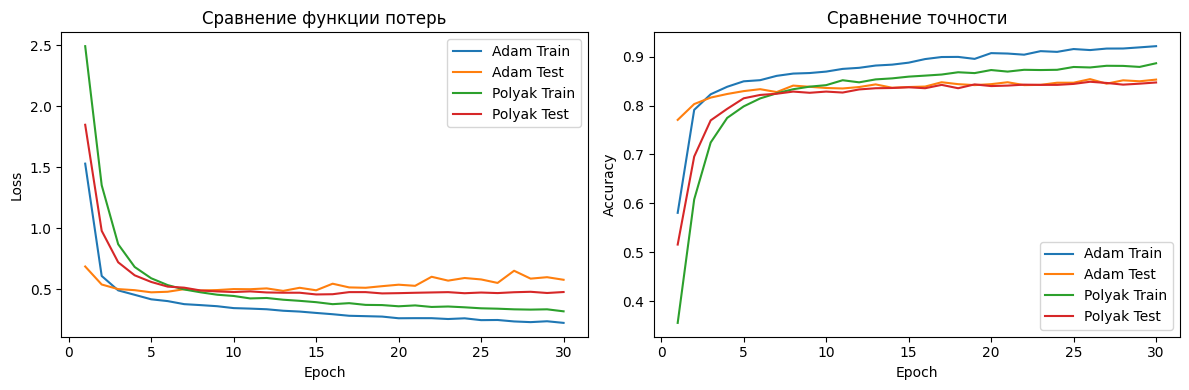

In [11]:
epochs = range(1, num_epochs+1)

# Потери
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history_adam['train_loss'], label='Adam Train')
plt.plot(epochs, history_adam['test_loss'], label='Adam Test')
plt.plot(epochs, history_polyak['train_loss'], label='Polyak Train')
plt.plot(epochs, history_polyak['test_loss'], label='Polyak Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Сравнение функции потерь')

# Точность
plt.subplot(1,2,2)
plt.plot(epochs, history_adam['train_acc'], label='Adam Train')
plt.plot(epochs, history_adam['test_acc'], label='Adam Test')
plt.plot(epochs, history_polyak['train_acc'], label='Polyak Train')
plt.plot(epochs, history_polyak['test_acc'], label='Polyak Test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Сравнение точности')
plt.tight_layout()
plt.show()